<a href="https://colab.research.google.com/github/seungheonbaek58-jpg/SCODA/blob/main/scoda_practice_workshop_1_scanpy_practice_260105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=blue> __Single-cell RNA-seq data analysis using SCANPY__  </font>

- 이 주피터 노트북은 단일세포 RNA-seq 데이터를 분석하기 위한 기초 실습을 포함합니다.
- SCANPY를 이용한 전처리, 시각화를 위한 기본적인 처리 과정에 대한 코드 예제를 제공합니다.
- Google Colab에서 실습하는 것을 가정하고 만들었으나 Anaconda 등이 설치된 개인 컴퓨터에서도 사용할 수 있습니다.
<br>

- __AnnData Format:__ https://anndata.readthedocs.io/en/stable/
- __SCANPY:__ https://scanpy.readthedocs.io/en/stable/
<br>

__MLBI-lab, July 21, 2025__

010-9530-5841

## __1. Install required packages and import them__
이제 파일이 준비되었으니 필요한 패키지를 설치하고 이를 불러와서(import해서) 데이터를 들여다 볼 수 있습니다.

In [1]:
## 필요한 패키지 설치 (이미 설치되었다면 skip 해도 됩니다.)
'''
!pip install gdown
!pip install numpy
!pip install pandas
!pip install scipy
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn
!pip install scikit-network   ### 코랩에는 이미 설치되어 있음, 다른 곳에서는 설치 필요
'''
!pip install leidenalg
!pip install scanpy
!pip install scoda-viz==0.4.31b
## This jupyter notebook was tested with the above version of scoda-viz package.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.2/174.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.7/165.7 kB 7.3 MB/s eta 0:00:00


In [2]:
## 필요한 패키지 불러오기
import copy, warnings, os
import anndata
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scodaviz import load_sample_data, plot_sankey, show_tree

warnings.filterwarnings('ignore')

https://github.com/combio-dku
INFO: statannotations was sucessfully installed.


## __Python의 데이터 구조들__

### __A. (가장 중요한) 데이터 프레임__
- 데이터 프레임이란? A: 엑셀 sheet 같은 것
- index (행이름)과 columns (열이름) 확인하기
- 데이터 프레임의 정렬, 최대값, 합/평균
- 조건설정과 boolean indexing

In [3]:
## Example Data Frame 불러와서 변수로 저장
df = sns.load_dataset('iris')

In [7]:
## Data Frame 확인하기
df.to_csv('iris.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['sepal_length'].plot(kind='hist', bins=20, title='sepal_length')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['sepal_width'].plot(kind='hist', bins=20, title='sepal_width')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['petal_length'].plot(kind='hist', bins=20, title='petal_length')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_16['petal_length'].plot(kind='line', figsize=(8, 4), title='petal_length')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['species'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='index', y='species', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['species'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='sepal_length', y='species', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['species'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='sepal_width', y='species', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['species'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='petal_length', y='species', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [14]:
print(f'df의 행 수는 {df.shape[0]} 입니다.')

df의 행 수는 150 입니다.


In [19]:
pd.set_option('display.max_rows', None)
display(df)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [10]:
## index와 columns 확인하기
df.index.values, df.columns.values

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149]),
 array(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
        'species'], dtype=object))

In [15]:
## 최대값, 평균, 합계 구하기 (숫자 컬럼에 대해서만)
df_numeric = df.select_dtypes(include=['number'])
print(f"최대값:\n{df_numeric.max()}\n")
print(f"평균:\n{df_numeric.mean()}\n")
print(f"합계:\n{df_numeric.sum()}")

최대값:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

평균:
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

합계:
sepal_length    876.5
sepal_width     458.6
petal_length    563.7
petal_width     179.9
dtype: float64


In [17]:
## 특정 항목(열) 기준으로 정렬하기
df.sort_values(by='sepal_length', ascending=False)

,sepal_length,sepal_width,petal_length,petal_width,species
131,7.9,3.8,6.4,2.0,virginica
122,7.7,2.8,6.7,2.0,virginica
118,7.7,2.6,6.9,2.3,virginica
117,7.7,3.8,6.7,2.2,virginica
135,7.7,3.0,6.1,2.3,virginica
105,7.6,3.0,6.6,2.1,virginica
130,7.4,2.8,6.1,1.9,virginica
107,7.3,2.9,6.3,1.8,virginica
109,7.2,3.6,6.1,2.5,virginica
129,7.2,3.0,5.8,1.6,virginica


In [56]:
set_display_rows(50)
display(df)

Pandas display option: 최대 50개의 행 표시.


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [53]:
def set_display_rows(num_rows=None):
    """
    Pandas DataFrame의 display.max_rows 설정을 변경하는 함수.
    num_rows가 None이면 모든 행을 표시하고, 숫자를 입력하면 해당 개수만큼 표시합니다.
    """
    pd.set_option('display.max_rows', num_rows)
    if num_rows is None:
        print("Pandas display option: 모든 행 표시.")
    else:
        print(f"Pandas display option: 최대 {num_rows}개의 행 표시.")

### __전체 행 표시하기__

In [54]:
# 모든 행을 표시하려면:
set_display_rows(None)
display(df)

Pandas display option: 모든 행 표시.


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [55]:
# 기본값 (예: 60개)으로 되돌리려면:
set_display_rows(60)
display(df.head())

# 또는 특정 개수 (예: 10개)만 표시하려면:
# set_display_rows(10)
# display(df)

Pandas display option: 최대 60개의 행 표시.


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
## 파일로 저장하고 저장했던 파일 불러오기


### __B. Python의 다른 데이터 구조들__
- <font color='blue'>string (문자열)</font>
- list
- <font color='blue'>dictionary</font>
- tuple
- set
- numpy.array


In [ ]:
## String 나누기, 붙이기 등

In [ ]:
## list 정의하기, 항목 추가하기, 항목 가져오기

In [33]:
## dictionary 정의하기, 항목 추가하기와 가져오기, key와 value 보기
d = {}
d["BSH"] = df
d["LJW"] = [2,3,4]
d.keys()


dict_keys(['BSH', 'LJW'])

In [ ]:
## numpy.array (list와 달리 모든 항목이 동일한 데이터 형)

list와 dictionary의 각 항목들은 데이터 타입이 달라도 되며 list나 또 다른 dictionary, 혹은 Data Frame을 값으로 가질 수 있습니다.

In [ ]:
## dictionary에 다양한 항목들 저장해 보기

In [34]:
## show_tree 함수로 dictionary 구조 보기
dct = {'A': 3, 'B': [1,2,3], 'DF': df, '또다른 dict': {1: df['species'], '2': df.columns.values} }

In [35]:
show_tree(dct)

Dictionary Structure (top-level):
├── A       : 3
├── B       : (list)
├── DF      : DataFrame (150, 5), cols=[sepal_length, sepal_width, petal_length, ... ])
└── 또다른 dict: (dict)
     ├── 1: array (shape=(150,), dtype=object)
     └── 2: array (shape=(5,), dtype=object)


## __2A. Download a sample data__

In [36]:
adata = load_sample_data( 'BC' )
adata

Downloading...
From (original): https://drive.google.com/uc?export=download&id=17FHZSTbvu9CO0pns5-3hcKl2LgLI7JF8
From (redirected): https://drive.google.com/uc?export=download&id=17FHZSTbvu9CO0pns5-3hcKl2LgLI7JF8&confirm=t&uuid=2f05a4db-c42c-4ab3-a2d1-462cd0853245
To: /content/downloaded
100%|██████████| 124M/124M [00:01<00:00, 94.7MB/s]


AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset'

## __2A. Or, Load your h5ad file__

In [37]:
file_h5ad = 'BRCA_GSE161529_33K_v1.h5ad'

In [38]:
adata = sc.read_h5ad(file_h5ad)
adata

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset'

## __3. Check your data__

#### __AnnData Format:__ https://anndata.readthedocs.io/en/stable/
  
<div>
<img src="https://drive.google.com/uc?export=view&id=1IGjZpO_DeaNFiX3u_fy_rnPC1oKwVsqU" align="center" width="500"/>
</div>
<div>
<img src="attachment:fefeae20-ad05-4cea-8327-72f3dd19903f.png" width="500"/>
</div>


obs와 var은 각각 세포와 유전자 description, 추가 설명

obsm, varm은 세포/유전자들의 묶음 정보를 저장할 때 유용, Ex, PCS clustering

obsp와 varp는 정사각형
- neighbor (인접한) matrix 정보 / correlation 정보 저장에 유용
- Ex. co-expression 정보, cell-cell interaction

uns = unstructured annotations
→ 비정형(구조 없는) 데이터 저장소입니다.

관측치(obs)나 변수(var)에 직접 매핑되지 않는

전체 데이터셋 수준의 정보나

분석 결과, 설정값, 메타정보를 저장하는 곳이에요

📦 파이썬 딕셔너리 (dict) 형태

In [39]:
adata

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset'

In [40]:
adata.obs.head()

,Patient,Description,Source,Condition,Menopause,Parity,Gender,geo_no,sid,n_genes_by_counts,...,total_counts_mt,pct_counts_mt,subtype,subtype_detail,tissue,condition,sample,celltype_major,celltype_minor,celltype_subset
GSM4909302_ER.MH0025_AGTCTTTGTTACCGAT-1,ER-MH0025,"ER+ tumor, total cells",Total,ER+ tumor,NaN,NaN,Female,GSM4909302,ER-MH0025,653,...,17.0,1.438240,ER+,ER+,NaN,ER+,ER-MH0025,Myeloid cell,Macrophage,Macrophage (M2D)
GSM4909302_ER.MH0025_CGGTTAACACGTCAGC-1,ER-MH0025,"ER+ tumor, total cells",Total,ER+ tumor,NaN,NaN,Female,GSM4909302,ER-MH0025,1559,...,181.0,3.857630,ER+,ER+,NaN,ER+,ER-MH0025,Epithelial cell,Epithelial cell,Luminal epithelial cell
GSM4909302_ER.MH0025_GTTTCTACATCGATTG-1,ER-MH0025,"ER+ tumor, total cells",Total,ER+ tumor,NaN,NaN,Female,GSM4909302,ER-MH0025,785,...,281.0,14.113511,ER+,ER+,NaN,ER+,ER-MH0025,Epithelial cell,Epithelial cell,Luminal epithelial cell
GSM4909302_ER.MH0025_TATCTCAGTGGCTCCA-1,ER-MH0025,"ER+ tumor, total cells",Total,ER+ tumor,NaN,NaN,Female,GSM4909302,ER-MH0025,391,...,53.0,8.412699,ER+,ER+,NaN,ER+,ER-MH0025,Myeloid cell,Macrophage,Macrophage (M2A)
GSM4909302_ER.MH0025_ACTTTCATCCGCGCAA-1,ER-MH0025,"ER+ tumor, total cells",Total,ER+ tumor,NaN,NaN,Female,GSM4909302,ER-MH0025,505,...,34.0,2.709163,ER+,ER+,NaN,ER+,ER-MH0025,T cell,T cell CD4+,T cell (Naive)


In [41]:
adata.var.head()

""
AL627309.1
AL669831.5
FAM87B
LINC00115
FAM41C


In [42]:
adata.obs[['condition']].value_counts()

,count
condition,
ER+,8994
Normal,8965
TNBC,8283
HER2+,7500


In [43]:
adata.obs[['sample']].value_counts()

,count
sample,
ER-MH0025,1500
ER-MH0029-7C,1500
ER-MH0043-T,1500
ER-MH0114-T3,1500
ER-MH0173-T,1500
...,...
N-PM0372-Total,1488
N-PM0230-Total,1485
TN-MH0135,1398


In [44]:
adata.obs.to_csv('obs.csv')

In [47]:
lst = [adata.obs['condition'], adata.obs['sample']]
plot_sankey(lst, title=None, fs=12, WH=(400, 600), th=30, title_y=0.85 )

## __4. Filtering cells and genes__
#### __Get statistics for Cell/Gene filtering__

In [48]:
adata
# condition 과 sample은 실험자가 정해주어야 한다
# cell type_major, minor, subset은 HiCAT 등 cell type annotation을 통해 생성됨
# 나머지 정보는 GEO에서 anndata로 가져온 것

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset'

In [46]:
show_tree( adata )

AnnData object with n_obs × n_vars = 33742 × 22585
├── X: array (shape=(33742, 22585), dtype=float32)
├── obs: DataFrame (33742, 21), cols=[Patient, Description, Source, ... ])
├── var: DataFrame (22585, 0), cols=[])
├── obsm: (AxisArrays)
│    └── (empty)
├── obsp: (PairwiseArrays)
│    └── (empty)
├── varm: (AxisArrays)
│    └── (empty)
├── varp: (PairwiseArrays)
│    └── (empty)
└── uns: (dict)
     └── (empty)


In [49]:
## select genes of which the name start with 'MT-', i.e., mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
## Boolean values saved to the new column named, 'mt' in var

In [51]:
adata.var

,mt
AL627309.1,False
AL669831.5,False
FAM87B,False
LINC00115,False
FAM41C,False
...,...
AL354822.1,False
AC004556.1,False
AC233755.2,False
AC233755.1,False


In [52]:
## Check the number of mitochondrial genes
display(adata.var['mt'].sum())

np.int64(13)

In [57]:
adata

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset'
    var: 'mt'

In [58]:
## Get stats
sc.pp.calculate_qc_metrics(adata, qc_vars = ['mt'], percent_top = None, \
                           log1p = False, inplace = True)

adata
## Results of this function are stored in new columns in the obs field

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

pp.calculate_qc_metrics: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html

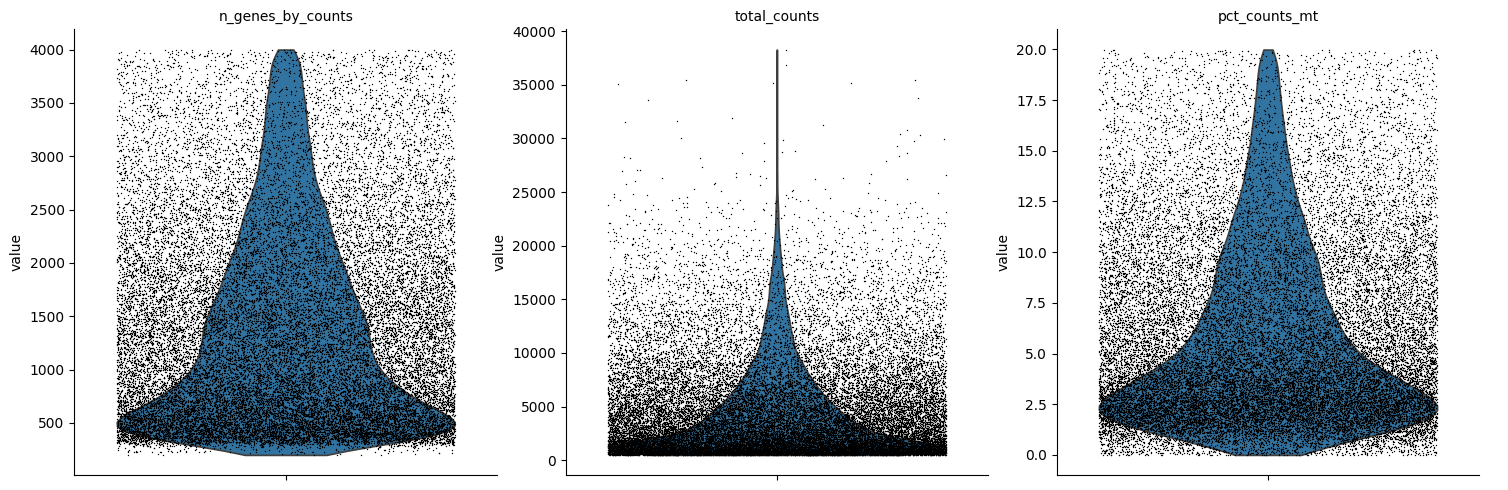

In [63]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)
# pct는 percentage

In [60]:
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].min()

,0
n_genes_by_counts,201.0
total_counts,499.0
pct_counts_mt,0.0


#### __Cell/Gene filtering__
- cell-by-gene count matrix에서 각 gene이 발현된 cell 수가 너무 적은 것은 제거
- 이를 위해 cell-by-gene count matrix를 data frame으로 가져와서
- 각 gene에 대해 0보다 큰 cell의 수를 계산하여
- 이 수를 기준으로 조건을 만들어서 filtering 함

#### Easy way to cell/gene filtering

In [62]:
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_cells(adata, max_genes = 4000) #이상이면 doublelet으로 봄
sc.pp.filter_genes(adata, min_cells = 20)

adata

AnnData object with n_obs × n_vars = 31676 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [64]:
adata.write('BC_filtered.h5ad')
#.h5ad = AnnData(단일세포 데이터)의 디스크 저장 형식
# (HDF5 기반, 대용량 데이터용)

In [65]:
b = adata.obs['pct_counts_mt'] <= 15
adata = adata[b, :]
adata

View of AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

## __5. Basic processings (Clustering & Visualization)__

#### __2차원 시각화(UMAP 또는 tSNE)를 위한 몇 가지 routine 한 step__
1. Count normalization: 각 행의 합(각 cell에 대한 RNA count의 총합)을 동일한 값(예 10,000)으로 맞춤
2. 1-augmented log-transform: Raw count의 확률분포를 정규분포에 가깝게 변환 (log변환 전 1을 더함)
3. highly variable gene selection: cell마다 값들의 변동이 큰 gene들을 확인하여 var field의 열('variable_gene')에 저장 - cell clustering을 더 잘 할 수도록 해줌
4. Dimension reduction using PCA: 선형변환 방식인 PCA를 이용하여 각 cell의 expression pattern(X의 각 행)을 차원 축소 -> obsm['X_pca']에 저장됨. (_Note:_ PCA를 위한 차원은 소위 'explained variance' plot을 보고 결정하면 좋지만 대략 15정도로 설정해도 무방함.)
5. Building Neighbor graph: PCA로 차원 축소한 벡터를 이용하여, 각 cell에 대해 expression pattern이 유사한 k개의 cell을 선택하여 이를 sparse matrix 형태로 저장 (matrix 크기는 cell수xcell수 이며 obsp field에 sparse matrix로 저장 됨.
6. UMAP or tSNE projection: Neighbor graph까지 얻어졌으면 umap 또는 tsne를 이용하여 2차원으로 차원 축소하여 산점도 확인 가능 - 차원축소 2단계로 진행
7. Clustering: 비슷한 expression pattern을 갖는 cell들을 하나의 클러스터로 그룹핑

In [66]:
## 1. Count normalization
sc.pp.normalize_total(adata, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [67]:
## 2. 1-augmented log-transform
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'

In [68]:
adata.uns['log1p']

{'base': None}

In [69]:
## 3. highly variable gene selection
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)
adata

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [70]:
adata.var['highly_variable'].sum()

np.int64(2000)

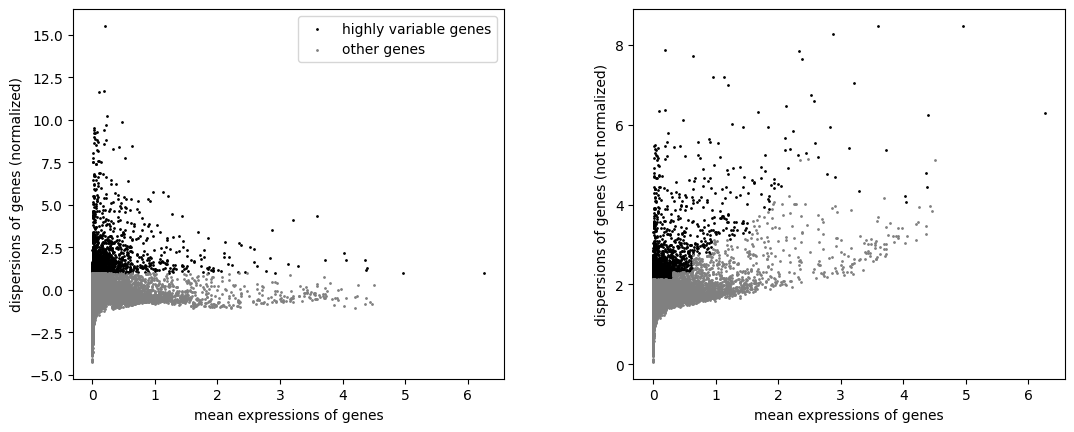

In [71]:
## check stats of highly-variable genes
sc.pl.highly_variable_genes(adata)

In [72]:
## 4. Dimension reduction using PCA
sc.tl.pca(adata, n_comps = 15, use_highly_variable = True)
adata

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [73]:
adata.uns['pca']

{'params': {'zero_center': True,
  'use_highly_variable': True,
  'mask_var': 'highly_variable'},
 'variance': array([24.075504 , 18.033474 , 14.110218 ,  8.895969 ,  6.6927214,
         5.6220827,  5.2768087,  4.1957088,  3.8235846,  3.5552516,
         3.179636 ,  2.9621868,  2.7823598,  2.2875917,  2.1568778],
       dtype=float32),
 'variance_ratio': array([0.08321258, 0.0623294 , 0.04876938, 0.03074729, 0.02313217,
        0.0194317 , 0.01823832, 0.0145017 , 0.01321552, 0.01228808,
        0.01098983, 0.01023826, 0.00961672, 0.00790664, 0.00745485],
       dtype=float32)}

In [75]:
adata.obsm['X_pca'].shape
# 15차원이기 때문에 한번더 차원축소해야 scatter plot 가능

(29912, 15)

In [76]:
## 5. Building Neighbor graph
# - cell 마다 10개 neighbor 생성 이를 바탕으로 2단계 차원축소
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15, use_rep = 'X_pca')
adata

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [78]:
adata.obsp['connectivities']
adata.obsp['connectivities'].todense() # dense matrix로 변환

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [79]:
## 6a: Compute UMAP projection
sc.tl.umap(adata)
adata

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
## 6b: tSNE projection (It takes time) - 시간 오래 걸림
sc.tl.tsne(adata)
adata

In [80]:
show_tree( adata )

AnnData object with n_obs × n_vars = 29912 × 20013
├── X: array (shape=(29912, 20013), dtype=float32)
├── obs: DataFrame (29912, 22), cols=[Patient, Description, Source, ... ])
├── var: DataFrame (20013, 10), cols=[mt, n_cells_by_counts, mean_counts, ... ])
├── obsm: (AxisArrays)
│    ├── X_pca : array (shape=(29912, 15), dtype=float32)
│    └── X_umap: array (shape=(29912, 2), dtype=float32)
├── obsp: (PairwiseArrays)
│    ├── distances     : array (shape=(29912, 29912), dtype=float32)
│    └── connectivities: array (shape=(29912, 29912), dtype=float32)
├── varm: (AxisArrays)
│    └── PCs: array (shape=(20013, 15), dtype=float64)
├── varp: (PairwiseArrays)
│    └── (empty)
└── uns: (dict)
     ├── log1p    : (dict)
     │    └── base: None
     ├── hvg      : (dict)
     │    └── flavor: 'seurat'
     ├── pca      : (dict)
     │    ├── params        : (dict) Keys=[zero_center, use_highly_variable, mask_var]
     │    ├── variance      : array (shape=(15,), dtype=float32)
     │    └─

In [81]:
adata.obsm['X_umap']

array([[ 0.10846342, -2.5636137 ],
       [ 2.3675623 ,  6.8748436 ],
       [ 2.9709337 ,  7.471164  ],
       ...,
       [ 8.321751  ,  4.094105  ],
       [ 8.251015  ,  5.310342  ],
       [ 8.843413  ,  5.323864  ]], dtype=float32)

In [82]:
## 7: Clustering using leiden algorithm
sc.tl.leiden(adata, resolution = 1, key_added = 'cluster')
## The clustering resolution was intentionally set low for quick example. Default value is 1.
adata
## resoultion이 높아질 수록 cluster 개수가 늘어난다

AnnData object with n_obs × n_vars = 29912 × 20013
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'sid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'celltype_major', 'celltype_minor', 'celltype_subset', 'n_genes', 'cluster'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cluster'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [83]:
adata.obs['cluster'].value_counts()

,count
cluster,
0,2207
1,2049
2,2026
3,1569
4,1447
5,1353
6,1340
7,1234
8,1140


## __6. Visualization__

#### 이제 UMAP 또는 tSNE 좌표를 이용해 대체적인 분포를 시각화해 볼 수 있습니다.

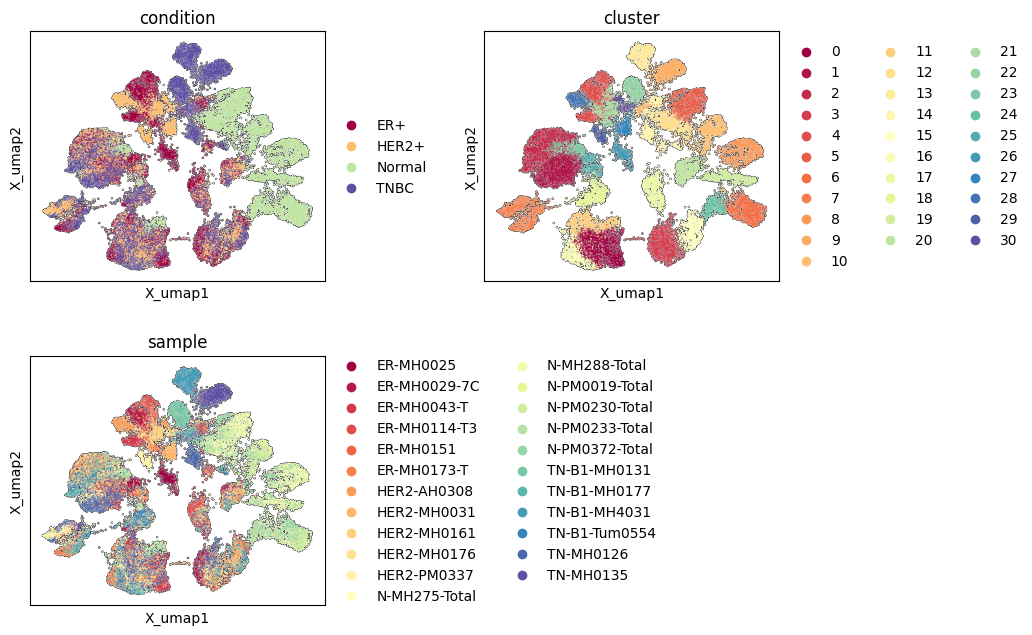

In [84]:
items_to_plot = ['condition', 'cluster', 'sample']

plt.rcParams['figure.figsize'] = (3.5, 3.5)
sc.pl.embedding( adata, color = items_to_plot,
                 basis = 'X_umap', neighbors_key = 'neighbors',
                 wspace = 0.4, hspace = 0.3, legend_fontsize = 10,
                 ncols = 2, palette = 'Spectral', add_outline = True)

## 이후 1 cluster 대비 나머지의 DEG를 구해서 해당 cluster의 marker를 찾고,
## 이를 통해 manual cell-type annotation을 할 수 있다

In [ ]:
items_to_plot = ['condition', 'cluster', 'sample']

plt.rcParams['figure.figsize'] = (3.5, 3.5)
sc.pl.embedding( adata, color = items_to_plot,
                 basis = 'X_tsne', neighbors_key = 'neighbors',
                 wspace = 0.4, hspace = 0.3, legend_fontsize = 10,
                 ncols = 2, palette = 'Spectral', add_outline = True)

#### 잘 알려진 몇가지 marker gene들의 발현량을 보면 어느 cluster가 무슨 세포유형인지 대략적으로 확인 가능

In [ ]:
genes_to_plot = ['CD3D', 'CD4', 'CD8A',     ## T cell markers
                 'CD79A', 'MS4A1', 'MZB1',  ## B cell markers
                 'CD14', 'LYZ',             ## Myeloid cell markers
                 'FBLN1', 'NOTCH3',         ## Stromal cells (Fibroblast, Smooth muscle cell) markers
                 'EPCAM', 'MUC1',           ## Epithelial cell markers
                 'CD34']                    ## Endothelial cell marker

plt.rcParams['figure.figsize'] = (3.5, 3.5)
sc.pl.embedding( adata, color = genes_to_plot + ['cluster'], use_raw = False,
                 basis = 'X_umap', neighbors_key = 'neighbors',
                 wspace = 0.2, hspace = 0.3, legend_fontsize = 8,
                 ncols = 3, palette = 'Spectral', add_outline = True, vmax = 'p99', vmin = 0)

#### Cluster 별 manual cell-type annotation을 할 때 요런 plot을 먼저 봅니다.

In [ ]:
genes_to_plot_dct = { 'T': ['CD3D', 'CD4', 'CD8A'],     ## T cell markers
                      'B': ['CD79A', 'MS4A1', 'MZB1'],  ## B cell markers
                      'M': ['CD14', 'LYZ'],             ## Myeloid cell markers
                      'S': ['FBLN1', 'NOTCH3'],         ## Stromal cells (Fibroblast, Smooth muscle cell) markers
                      'Epi': ['EPCAM', 'MUC1'],         ## Epithelial cell markers
                      'Endo': ['CD34'] }                ## Endothelial cell marker

In [ ]:
sc.pl.stacked_violin(adata, genes_to_plot_dct, groupby='cluster', figsize = (6,6))

In [ ]:
adata.obs['my_celltype_annot'] = 'NA'
b = adata.obs['cluster'].isin( ['0', '11', '16'] )
adata.obs.loc[b, 'my_celltype_annot'] = 'M'

b = adata.obs['cluster'].isin( ['1', '2', '23', '25'] )
adata.obs.loc[b, 'my_celltype_annot'] = 'T'

In [ ]:
plt.rcParams['figure.figsize'] = (3.5, 3.5)
sc.pl.embedding( adata, color = items_to_plot + ['my_celltype_annot', 'CD3D', 'LYZ'],
                 basis = 'X_tsne', neighbors_key = 'neighbors',
                 wspace = 0.4, hspace = 0.3, legend_fontsize = 10,
                 ncols = 2, palette = 'Spectral', add_outline = True)

In [ ]:
sc.pl.dotplot(adata, genes_to_plot_dct, groupby='cluster', figsize = (6,6))

In [ ]:
fig, axes = plt.subplots(len(genes_to_plot), 1, figsize=(8, 2*len(items_to_plot)), dpi = 80)
plt.subplots_adjust(hspace = 0.9)

for j, item in enumerate(genes_to_plot):
    sc.pl.violin(adata, [item], groupby='cluster', ax = axes[j], use_raw = False, stripplot = False, show = False)

In [ ]:
genes_to_plot_dct = {'T': ['CD3D', 'CD4', 'CD8A'],     ## T cell markers
                 'B': ['CD79A', 'MS4A1', 'MZB1'],  ## B cell markers
                 'M': ['CD14', 'LYZ'],             ## Myeloid cell markers
                 'S': ['FBLN1', 'NOTCH3'],         ## Stromal cells (Fibroblast, Smooth muscle cell) markers
                 'Epi': ['EPCAM', 'MUC1'],           ## Epithelial cell markers
                 'Endo': ['CD34'] }                   ## Endothelial cell marker


sc.pl.heatmap( adata, var_names = genes_to_plot_dct, groupby = 'cluster',
               var_group_labels = genes_to_plot_dct.keys(),
               standard_scale = True, figsize = (6, 8) )

## __7. DEG Analysis (among clusters)__

In [ ]:
adata

In [ ]:
test_sel = 't-test'  ## 'logreg', 't-test', 'wilcoxon', 't-test_overestim_var'
sc.tl.rank_genes_groups(adata, groupby = 'cluster', method=test_sel,
                        key_added = test_sel, pts = True)
adata

In [ ]:
adata.uns['t-test'].keys()

#### Get DEG results in data frame

In [ ]:
target_cluster = '1'
gene_rank = sc.get.rank_genes_groups_df(adata, group = target_cluster,
                                        key = test_sel, pval_cutoff = 0.01,
                                        log2fc_min = 0.25)
gene_rank.iloc[:30]

In [ ]:
gene_rank.shape

In [ ]:
target_cluster = '18'
gene_rank = sc.get.rank_genes_groups_df(adata, group = target_cluster,
                                        key = test_sel, pval_cutoff = 0.01,
                                        log2fc_min = 0.25)
gene_rank.iloc[:30]

#### Show the DEG results

In [ ]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False,
                        key = test_sel, fontsize = 6)